# 02 - The 2D Gaussian primitive

Notebook 01 ended with a requirement: a primitive with screen extent. The
obvious candidate is a hard-edged disk. Two local problems with it: the edge
is a step function, so it aliases into staircases at every silhouette, and
where two disks meet, one pixel flips ownership discontinuously as the camera
moves, which reads as crawling edges. Both problems come from the hard edge,
so the fix is a primitive whose coverage falls off smoothly.

The Gaussian is the falloff we pick. The local reasons: one closed formula
covers every ellipse at every orientation, it is cheap to evaluate, and it is
smooth everywhere. Deeper reasons surface in notebook 04 when we have to push
one through a projection; no dependency on that yet.

## 1D, and a deliberate difference from statistics

```
G(x) = exp(-(x - mu)^2 / (2 sigma^2))
```

No `1/(sigma sqrt(2 pi))` in front. This is not a probability density; it is
an opacity profile. Dropping the normalizer pins the peak at exactly 1.0, so
a separate learned opacity `o` scales the whole splat and `o` means "opacity
at the center" with no coupling to the splat's size.

## 2D

```
G(x) = exp(-0.5 * (x - mu)^T Sigma^-1 (x - mu))
```

`Sigma` is 2x2, symmetric, positive definite. The scalar in the exponent is
squared Mahalanobis distance; its level sets are ellipses. A 2D Gaussian is
an ellipse with soft falloff, nothing more.

Reading `Sigma = [[a, b], [b, c]]`: eigenvectors are the ellipse axes,
eigenvalues are the squared semi-axis lengths (in sigmas), `b = 0` means
axis-aligned.

## Never build Sigma from raw entries

Build it as a product:

```
M = R S          (rotation times diagonal scale)
Sigma = M M^T = R S S^T R^T
```

Any `M M^T` is positive semi-definite by construction: for every vector v,
`v^T M M^T v = |M^T v|^2 >= 0`. Optimize `a, b, c` as free numbers instead
and gradient descent will eventually produce a negative eigenvalue. Then
`Sigma^-1` has a negative eigenvalue too, the exponent turns positive along
that axis, and the splat grows without bound instead of falling off. We
demonstrate the explosion below. This is why 3DGS stores scale + rotation
rather than covariance entries.

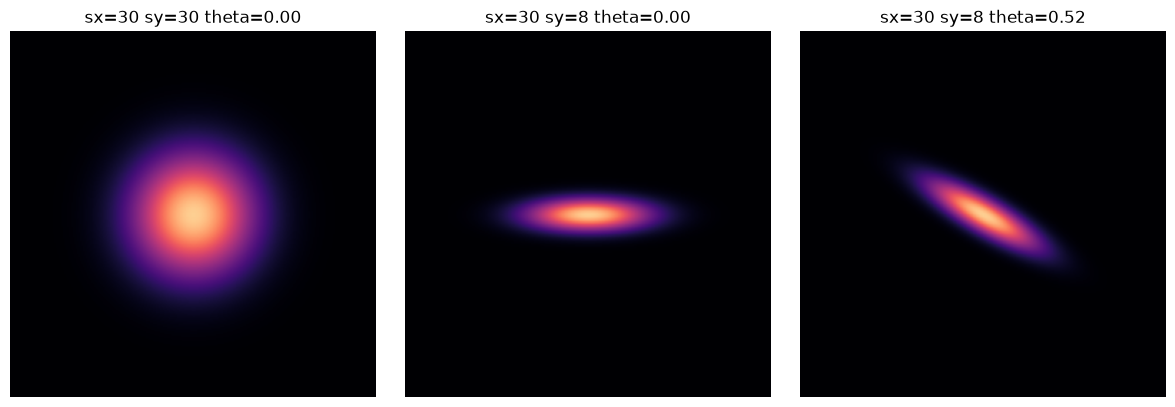

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

def cov2d(sx, sy, theta):
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s], [s, c]])
    M = R @ np.diag([sx, sy])
    return M @ M.T

def splat_window(mu, cov, o, x0, x1, y0, y1):
    """Evaluate o * G over the pixel window [x0,x1) x [y0,y1)."""
    Sinv = np.linalg.inv(cov)
    A, B, Cc = Sinv[0, 0], Sinv[0, 1], Sinv[1, 1]   # the "conic"
    ys, xs = np.mgrid[y0:y1, x0:x1]
    dx, dy = xs - mu[0], ys - mu[1]
    power = -0.5 * (A * dx * dx + Cc * dy * dy) - B * dx * dy
    return o * np.exp(power)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (sx, sy, t) in zip(axes, [(30, 30, 0), (30, 8, 0), (30, 8, np.pi / 6)]):
    ax.imshow(splat_window((128, 128), cov2d(sx, sy, t), 0.9, 0, 256, 0, 256),
              cmap="magma", vmin=0, vmax=1)
    ax.set_title(f"sx={sx} sy={sy} theta={t:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

Implementation notes that persist all the way to the CUDA kernel: the inverse
covariance (the conic) is computed once per splat, never per pixel; and in
2D the inverse is written by hand,
`det = a c - b^2`, `Sigma^-1 = (1/det) [[c, -b], [-b, a]]`.

## What a broken Sigma looks like

`[[4, 3], [3, 2]]` has `det = -1`: eigenvalues of opposite sign. Legal to
invert, catastrophic to exponentiate.

eigenvalues: [-0.16227766  6.16227766]
max value in window: inf


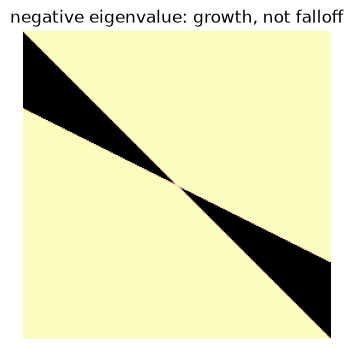

In [2]:
bad = np.array([[4.0, 3.0], [3.0, 2.0]])
print("eigenvalues:", np.linalg.eigvalsh(bad))
with np.errstate(over="ignore"):
    vals = splat_window((128, 128), bad, 0.9, 0, 256, 0, 256)
print("max value in window:", vals.max())        # inf: grows toward the corners
plt.figure(figsize=(4, 4))
plt.imshow(np.clip(vals, 0, 1), cmap="magma")
plt.title("negative eigenvalue: growth, not falloff")
plt.axis("off")
plt.show()

## Truncation: where to cut a function that never reaches zero

A Gaussian is nonzero everywhere. Taken literally, every splat touches every
pixel and rendering is O(splats x pixels). So we truncate. Where?

Value at radius `r` sigmas is `exp(-r^2 / 2)`:

In [3]:
for r in (1, 2, 3, 4):
    print(f"r = {r}:  exp(-r^2/2) = {np.exp(-r * r / 2):.5f}")

r = 1:  exp(-r^2/2) = 0.60653
r = 2:  exp(-r^2/2) = 0.13534
r = 3:  exp(-r^2/2) = 0.01111
r = 4:  exp(-r^2/2) = 0.00034


Two forces set the cut. Pixels touched grow as r^2, so extending 3 -> 4
costs 78% more area. And the output is 8-bit: any contribution below
`1/255 = 0.0039` cannot change a pixel. That floor gives an exact cutoff for
a splat of opacity `o`:

```
o * exp(-r^2/2) < 1/255   =>   r > sqrt(2 ln(255 o))

o = 1.0  ->  r = 3.33
o = 0.5  ->  r = 3.11
o = 0.1  ->  r = 2.55
```

So the conventional 3-sigma cut is not conservative. For `o > 0.35` it clips
contributions that would have been visible, up to a few LSBs from a single
splat. It survives in 3DGS because training renders through the same clipped
rasterizer: the optimizer fits Gaussians to the renderer that clips, so the
error lands inside the fit instead of on top of a correct answer.

This also explains why there are two cutoffs, not one. The 3-sigma radius is
a cheap conservative bound, computed once per splat, deciding which pixels to
visit at all. The `alpha < 1/255` test is the exact per-pixel cutoff, and it
is free because alpha is already in hand.

## The radius, in closed form

The bounding radius needs the largest eigenvalue of Sigma. For a 2x2 there is
a closed form the CUDA kernel will use verbatim:

```
mid  = (a + c) / 2
lam_max = mid + sqrt(mid^2 - det)
radius  = ceil(3 * sqrt(lam_max))
```

In [4]:
def radius_3sigma(cov):
    a, b, c = cov[0, 0], cov[0, 1], cov[1, 1]
    det = a * c - b * b
    mid = 0.5 * (a + c)
    lam_max = mid + np.sqrt(max(0.1, mid * mid - det))
    return int(np.ceil(3 * np.sqrt(lam_max)))

S = cov2d(30, 8, np.pi / 6)
lam = np.linalg.eigvalsh(S)
mid = 0.5 * (S[0, 0] + S[1, 1])
det = np.linalg.det(S)
assert np.allclose(sorted([mid - np.sqrt(mid**2 - det), mid + np.sqrt(mid**2 - det)]),
                   lam)
assert np.allclose(lam, [64, 900])   # rotation leaves eigenvalues at sx^2, sy^2
print("radius:", radius_3sigma(S), "px")

radius: 90 px


## What truncation buys

In [5]:
mu, o = (128.0, 128.0), 0.9
r = radius_3sigma(S)
x0, x1 = int(mu[0]) - r, int(mu[0]) + r + 1
y0, y1 = int(mu[1]) - r, int(mu[1]) + r + 1

t0 = time.perf_counter()
for _ in range(200):
    splat_window(mu, S, o, 0, 256, 0, 256)
t_full = (time.perf_counter() - t0) / 200

t0 = time.perf_counter()
for _ in range(200):
    splat_window(mu, S, o, x0, x1, y0, y1)
t_bbox = (time.perf_counter() - t0) / 200

print(f"full frame: {256*256} px, {t_full*1e3:.2f} ms")
print(f"3-sigma bbox: {(x1-x0)*(y1-y0)} px, {t_bbox*1e3:.2f} ms")

full frame: 65536 px, 0.46 ms
3-sigma bbox: 32761 px, 0.25 ms


## The small-splat failure

Notebook 01's exercise predicted it: footprints shrink below a pixel at
distance. Force it now with `sy = 0.15` px. The splat is a sub-pixel sliver,
and we are point-sampling, at pixel centers, a function whose energy lives
above the Nyquist frequency of the pixel grid. Slide the mean by fractions of
a pixel and watch the sampled peak:

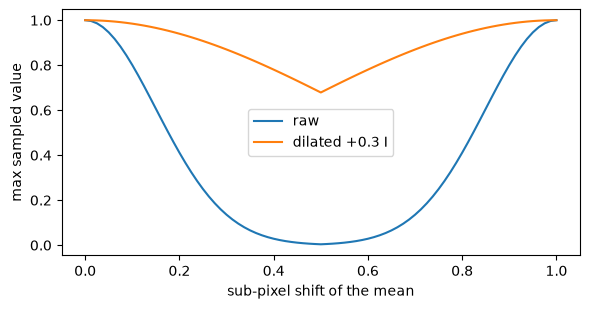

In [6]:
thin = cov2d(6, 0.15, 0.0)
shifts = np.linspace(0, 1, 81)

def peak_vs_shift(cov):
    return [splat_window((16.0, 16.0 + t), cov, 1.0, 0, 33, 0, 33).max()
            for t in shifts]

plt.figure(figsize=(6, 3.2))
plt.plot(shifts, peak_vs_shift(thin), label="raw")
plt.plot(shifts, peak_vs_shift(thin + 0.3 * np.eye(2)), label="dilated +0.3 I")
plt.xlabel("sub-pixel shift of the mean")
plt.ylabel("max sampled value")
plt.legend()
plt.tight_layout()
plt.show()

Raw: the splat blinks between ~1.0 and ~0.004 depending on where the mean
lands relative to the grid. In a still frame that is speckle; under camera
motion it is flicker.

## The fix: band-limit before sampling

Standard signal processing: convolve the signal with a reconstruction filter
matched to the pixel grid, then sample. Normally a convolution is expensive.
Here it is two additions, because convolving two Gaussians yields a Gaussian
whose covariance is the sum:

```
G(0, A) conv G(0, B) = G(0, A + B)
```

Choose an isotropic prefilter with variance `h` per axis and the entire
band-limiting step is

```
Sigma -> Sigma + h I
```

3DGS uses `h = 0.3`, flooring every screen-space sigma at
`sqrt(0.3) ~ 0.55` px. The orange curve above shows the result: the sampled
peak barely moves as the mean slides.

## The bug the fix introduces

The integral of the unnormalized kernel over the plane is

```
integral of o * exp(-0.5 d^T Sigma^-1 d)  =  o * 2 pi sqrt(det Sigma)
```

Dilation raises `det Sigma` and leaves `o` alone, so the splat gains energy.
A thin splat gets brighter as a side effect of being anti-aliased:

In [7]:
def energy(cov, o=1.0):
    return o * 2 * np.pi * np.sqrt(np.linalg.det(cov))

dil = thin + 0.3 * np.eye(2)
print(f"intended energy:      {energy(thin):.2f}")
print(f"energy after +0.3 I:  {energy(dil):.2f}")
print(f"discrete pixel sum:   {splat_window((64, 64), dil, 1.0, 0, 128, 0, 128).sum():.2f}")

comp = np.sqrt(np.linalg.det(thin) / np.linalg.det(dil))
print(f"compensation o' = o * sqrt(det/det_dilated) = o * {comp:.3f}")
print(f"compensated energy:   {energy(dil, comp):.2f}")

intended energy:      5.65
energy after +0.3 I:  21.50
discrete pixel sum:   21.57
compensation o' = o * sqrt(det/det_dilated) = o * 0.263
compensated energy:   5.65


The correction `o' = o * sqrt(det Sigma / det(Sigma + h I))` restores the
integral. It is exactly the fix Mip-Splatting (Yu et al., CVPR 2024) adds to
3DGS. The original skips it and lets training absorb the brightness error,
the same move as with the 3-sigma clip. Our renderer implements the plain
version first; we add compensation when the artifact shows up on real scenes.

## Check yourself

Model a receding splat as `Sigma(t) = t^2 Sigma0` with `t -> 0` (notebook 04
will show screen covariance really does scale this way with distance). With
dilation, what does the rendered footprint converge to, and what does its
energy do relative to the intended `o * 2 pi t^2 sqrt(det Sigma0)`? What does
a field of distant splats therefore look like, with and without compensation?

Answer it, then read on.

## Answer

`Sigma(t) + 0.3 I -> 0.3 I`: every sufficiently distant splat renders as the
same isotropic dot, sigma ~ 0.55 px, peak value `o`. Its energy converges to
`o * 2 pi * 0.3`, a constant, while the intended energy vanishes as `t^2`.
So without compensation, distant geometry refuses to fade: it renders as a
field of fixed-size, full-opacity dots, too bright and too thick, and it
shimmers as those dots re-sort. With compensation,
`o' = o * sqrt(det(t^2 Sigma0) / det(t^2 Sigma0 + 0.3 I)) -> 0` like `t^2`,
and distance dims splats the way it should.

Next: the ellipse has to come from a 3D object. Notebook 03.